# Bloque 1 - Análisis exploratorio con PySpark

## Reporte de delitos sexuales - Policía Nacional

### Natalia Zárate Yara

**Fuente:** DIJIN - Policía Nacional, publicado en datos.gov.co

**Base:** `data/raw/reporte_delitos_sexuales_policia_20260527.csv`

**Periodo:** 2010 a marzo de 2026

Este notebook estudia los reportes registrados de delitos sexuales en Colombia. La base representa casos reportados o registrados, no necesariamente la ocurrencia real total del fenómeno.

## Preguntas de análisis

1. ¿Cómo ha cambiado el número de reportes entre 2010 y 2025?
2. ¿En qué departamentos se concentra la mayor cantidad de reportes?
3. ¿Qué grupos de género y edad aparecen con mayor frecuencia en los registros?
4. ¿Qué tipos de delito y medios reportados son más frecuentes?
5. ¿Qué limitaciones de calidad de datos deben tenerse en cuenta antes de hacer Machine Learning?

## 1. Configuración inicial

Se importan las librerías, se crea la sesión de Spark y se fija un estilo básico para los gráficos.

In [1]:
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("bloque1_eda_delitos_sexuales")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 2. Carga del dataset con PySpark

Se define el esquema manualmente para evitar que Spark interprete mal algunos campos.

In [2]:
possible_paths = [
    Path("data/raw/reporte_delitos_sexuales_policia_20260527.csv"),
    Path("../data/raw/reporte_delitos_sexuales_policia_20260527.csv"),
]

DATA_PATH = next(path for path in possible_paths if path.exists())
print(f"Archivo utilizado: {DATA_PATH.resolve()}")

schema = StructType([
    StructField("DEPARTAMENTO", StringType(), True),
    StructField("MUNICIPIO", StringType(), True),
    StructField("CODIGO DANE", StringType(), True),
    StructField("ARMAS MEDIOS", StringType(), True),
    StructField("FECHA HECHO", StringType(), True),
    StructField("GENERO", StringType(), True),
    StructField("GRUPO ETARIO", StringType(), True),
    StructField("CANTIDAD", IntegerType(), True),
    StructField("delito", StringType(), True),
])

df_raw = (
    spark.read
    .option("header", True)
    .option("encoding", "UTF-8")
    .schema(schema)
    .csv(str(DATA_PATH))
)

df_raw.printSchema()
print(f"Número de registros: {df_raw.count():,}")
df_raw.show(10, truncate=False)

Archivo utilizado: /home/jovyan/work/data/raw/reporte_delitos_sexuales_policia_20260527.csv
root
 |-- DEPARTAMENTO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CODIGO DANE: string (nullable = true)
 |-- ARMAS MEDIOS: string (nullable = true)
 |-- FECHA HECHO: string (nullable = true)
 |-- GENERO: string (nullable = true)
 |-- GRUPO ETARIO: string (nullable = true)
 |-- CANTIDAD: integer (nullable = true)
 |-- delito: string (nullable = true)

Número de registros: 392,576
+------------+-------------+-----------+------------+-----------+---------+------------+--------+-------------------------------------------------------------------------+
|DEPARTAMENTO|MUNICIPIO    |CODIGO DANE|ARMAS MEDIOS|FECHA HECHO|GENERO   |GRUPO ETARIO|CANTIDAD|delito                                                                   |
+------------+-------------+-----------+------------+-----------+---------+------------+--------+--------------------------------------------------------

Se carga el CSV original con PySpark y se revisa la estructura. La base tiene 392.576 registros y 9 columnas. Se confirma que `CANTIDAD` es numérica y que `CODIGO DANE` se conserva como texto porque es un identificador.

## 3. Limpieza básica y variables derivadas

Se renombran las columnas, se convierte la fecha y se crean variables de año, mes y trimestre. Dado que 2026 está incompleto, los análisis de tendencia anual se hacen con 2010-2025. Además, se reemplazaron los nulos de género y grupo etario por una categoría de no reporte.

In [3]:
df = (
    df_raw
    .withColumnRenamed("CODIGO DANE", "CODIGO_DANE")
    .withColumnRenamed("ARMAS MEDIOS", "ARMAS_MEDIOS")
    .withColumnRenamed("FECHA HECHO", "FECHA_HECHO")
    .withColumnRenamed("GRUPO ETARIO", "GRUPO_ETARIO")
    .withColumn("FECHA", F.to_date("FECHA_HECHO", "dd/MM/yyyy"))
    .withColumn("ANIO", F.year("FECHA"))
    .withColumn("MES", F.month("FECHA"))
    .withColumn("TRIMESTRE", F.quarter("FECHA"))
    .withColumn("GENERO_LIMPIO", F.coalesce(F.col("GENERO"), F.lit("NO REPORTA")))
    .withColumn("GRUPO_ETARIO_LIMPIO", F.coalesce(F.col("GRUPO_ETARIO"), F.lit("NO REPORTA")))
)

df = df.cache()
df.select("DEPARTAMENTO", "MUNICIPIO", "FECHA", "ANIO", "MES", "GENERO_LIMPIO", "GRUPO_ETARIO_LIMPIO", "CANTIDAD", "delito").show(8, truncate=False)

+------------+-------------+----------+----+---+-------------+-------------------+--------+-------------------------------------------------------------------------+
|DEPARTAMENTO|MUNICIPIO    |FECHA     |ANIO|MES|GENERO_LIMPIO|GRUPO_ETARIO_LIMPIO|CANTIDAD|delito                                                                   |
+------------+-------------+----------+----+---+-------------+-------------------+--------+-------------------------------------------------------------------------+
|PUTUMAYO    |Mocoa (CT)   |2010-02-04|2010|2  |FEMENINO     |ADULTOS            |1       |ARTÍCULO 210 A. ACOSO SEXUAL                                             |
|CASANARE    |Aguazul      |2010-02-23|2010|2  |FEMENINO     |ADOLESCENTES       |1       |ARTÍCULO 206. ACTO SEXUAL VIOLENTO                                       |
|CASANARE    |Aguazul      |2010-02-11|2010|2  |FEMENINO     |ADULTOS            |1       |ARTÍCULO 206. ACTO SEXUAL VIOLENTO                                       |
|VAL

## 4. Transformaciones analíticas con PySpark

### 4.1 Filter: análisis con años completos

In [4]:
df_2010_2025 = df.filter((F.col("ANIO") >= 2010) & (F.col("ANIO") <= 2025))

print(f"Registros 2010-2025: {df_2010_2025.count():,}")
df_2010_2025.groupBy("ANIO").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy("ANIO").show(20)

Registros 2010-2025: 386,224
+----+--------------+
|ANIO|TOTAL_REPORTES|
+----+--------------+
|2010|          6887|
|2011|          8249|
|2012|         11488|
|2013|         11732|
|2014|         12789|
|2015|         21929|
|2016|         23954|
|2017|         28372|
|2018|         36815|
|2019|         38185|
|2020|         30922|
|2021|         34727|
|2022|         27663|
|2023|         28053|
|2024|         31474|
|2025|         32985|
+----+--------------+



Se filtran años completos, de 2010 a 2025, con lo que quedan 386.224 reportes. La serie anual muestra un crecimiento fuerte hasta 2019, una caída en 2020 y una recuperación en años posteriores.

### 4.2 GroupBy: concentración territorial

In [5]:
casos_por_departamento = (
    df_2010_2025
    .groupBy("DEPARTAMENTO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .orderBy(F.desc("TOTAL_REPORTES"))
)

casos_por_departamento.show(15, truncate=False)

+------------------+--------------+
|DEPARTAMENTO      |TOTAL_REPORTES|
+------------------+--------------+
|BOGOTA            |70515         |
|ANTIOQUIA         |47705         |
|VALLE             |36566         |
|SANTANDER         |22674         |
|CUNDINAMARCA      |19354         |
|ATLÁNTICO         |16014         |
|TOLIMA            |13997         |
|HUILA             |13729         |
|BOLÍVAR           |13036         |
|META              |11916         |
|BOYACÁ            |11026         |
|NARIÑO            |10810         |
|RISARALDA         |10099         |
|CAUCA             |9894          |
|NORTE DE SANTANDER|8744          |
+------------------+--------------+
only showing top 15 rows



Se agrupan los reportes por departamento. Bogotá, Antioquia y Valle son los territorios con más registros acumulados. Esto no significa necesariamente mayor riesgo, porque no se están usando tasas poblacionales.

### 4.3 WithColumn: clasificación temporal sencilla

Se crea una variable que separa los años antes de pandemia, pandemia y después de pandemia. Esta variable organiza la comparación temporal.

In [6]:
df_periodos = (
    df_2010_2025
    .withColumn(
        "PERIODO",
        F.when(F.col("ANIO") <= 2019, "2010-2019")
         .when(F.col("ANIO").isin(2020, 2021), "2020-2021")
         .otherwise("2022-2025")
    )
)

df_periodos.groupBy("PERIODO").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy("PERIODO").show()

+---------+--------------+
|  PERIODO|TOTAL_REPORTES|
+---------+--------------+
|2010-2019|        200400|
|2020-2021|         65649|
|2022-2025|        120175|
+---------+--------------+



El periodo 2010-2019 acumula 200.400 reportes, 2020-2021 acumula 65.649 y 2022-2025 acumula 120.175. Esta comparación organiza el tiempo, pero no prueba causalidad.

### 4.4 Join: agregar región geográfica

In [7]:
region_data = [
    ("AMAZONAS", "Amazonía"), ("CAQUETÁ", "Amazonía"), ("GUAINÍA", "Amazonía"), ("GUAVIARE", "Amazonía"), ("PUTUMAYO", "Amazonía"), ("VAUPÉS", "Amazonía"),
    ("ANTIOQUIA", "Andina"), ("BOGOTA", "Andina"), ("BOYACÁ", "Andina"), ("CALDAS", "Andina"), ("CUNDINAMARCA", "Andina"), ("HUILA", "Andina"), ("NORTE DE SANTANDER", "Andina"), ("QUINDÍO", "Andina"), ("RISARALDA", "Andina"), ("SANTANDER", "Andina"), ("TOLIMA", "Andina"),
    ("ATLÁNTICO", "Caribe"), ("BOLÍVAR", "Caribe"), ("CESAR", "Caribe"), ("CÓRDOBA", "Caribe"), ("GUAJIRA", "Caribe"), ("MAGDALENA", "Caribe"), ("SAN ANDRÉS", "Caribe"), ("SUCRE", "Caribe"),
    ("ARAUCA", "Orinoquía"), ("CASANARE", "Orinoquía"), ("META", "Orinoquía"), ("VICHADA", "Orinoquía"),
    ("CAUCA", "Pacífica"), ("CHOCÓ", "Pacífica"), ("NARIÑO", "Pacífica"), ("VALLE", "Pacífica"),
]

df_regiones = spark.createDataFrame(region_data, ["DEPARTAMENTO", "REGION"])

df_con_region = df_2010_2025.join(df_regiones, on="DEPARTAMENTO", how="left")

df_con_region.groupBy("REGION").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy(F.desc("TOTAL_REPORTES")).show(truncate=False)

+---------+--------------+
|REGION   |TOTAL_REPORTES|
+---------+--------------+
|Andina   |230893        |
|Caribe   |64614         |
|Pacífica |60188         |
|Orinoquía|18748         |
|Amazonía |11781         |
+---------+--------------+



Se agrega una tabla manual de regiones y se une con el dataset. La región Andina concentra 230.893 reportes, seguida por la región Caribe y Pacífica.

## 5. Estadística descriptiva

En esta base `CANTIDAD` vale 1 en todos los registros y las estadísticas descriptivas en meses y año tampoco tienen mucho sentido. Por eso, los análisis con valor real son los conteos agregados por año, departamento, género, grupo etario y delito.

In [8]:
df.select("CANTIDAD", "ANIO", "MES", "TRIMESTRE").describe().show()
df.select("CANTIDAD", "ANIO", "MES", "TRIMESTRE").summary().show()

percentiles_anio = df.approxQuantile("ANIO", [0.25, 0.5, 0.75], 0.01)
percentiles_mes = df.approxQuantile("MES", [0.25, 0.5, 0.75], 0.01)
percentiles_cantidad = df.approxQuantile("CANTIDAD", [0.25, 0.5, 0.75, 0.95, 0.99], 0.01)

print("Percentiles de ANIO (25%, 50%, 75%):", percentiles_anio)
print("Percentiles de MES (25%, 50%, 75%):", percentiles_mes)
print("Percentiles de CANTIDAD:", percentiles_cantidad)

+-------+--------+------------------+------------------+------------------+
|summary|CANTIDAD|              ANIO|               MES|         TRIMESTRE|
+-------+--------+------------------+------------------+------------------+
|  count|  392576|            392576|            392576|            392576|
|   mean|     1.0|2019.2533420280404| 6.303686419954353|2.4401389794587547|
| stddev|     0.0|3.9854321793443366|3.3727749765599824|1.1051053172684764|
|    min|       1|              2010|                 1|                 1|
|    max|       1|              2026|                12|                 4|
+-------+--------+------------------+------------------+------------------+

+-------+--------+------------------+------------------+------------------+
|summary|CANTIDAD|              ANIO|               MES|         TRIMESTRE|
+-------+--------+------------------+------------------+------------------+
|  count|  392576|            392576|            392576|            392576|
|   mean|  

### 5.1 Conteos por categoría

In [9]:
print("Reportes por género")
df_2010_2025.groupBy("GENERO_LIMPIO").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy(F.desc("TOTAL_REPORTES")).show(truncate=False)


print("Reportes por grupo etario")
df_2010_2025.groupBy("GRUPO_ETARIO_LIMPIO").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy(F.desc("TOTAL_REPORTES")).show(truncate=False)

print("Tipos de delito más frecuentes")
df_2010_2025.groupBy("delito").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy(F.desc("TOTAL_REPORTES")).show(12, truncate=False)

print("Medios o armas más frecuentes")
df_2010_2025.groupBy("ARMAS_MEDIOS").agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES")).orderBy(F.desc("TOTAL_REPORTES")).show(12, truncate=False)

Reportes por género
+-------------+--------------+
|GENERO_LIMPIO|TOTAL_REPORTES|
+-------------+--------------+
|FEMENINO     |325377        |
|MASCULINO    |58138         |
|NO REPORTA   |2709          |
+-------------+--------------+

Reportes por grupo etario
+-------------------+--------------+
|GRUPO_ETARIO_LIMPIO|TOTAL_REPORTES|
+-------------------+--------------+
|ADULTOS            |241121        |
|MENORES            |77540         |
|ADOLESCENTES       |67052         |
|NO REPORTA         |511           |
+-------------------+--------------+

Tipos de delito más frecuentes
+---------------------------------------------------------------------------------------------------------------+--------------+
|delito                                                                                                         |TOTAL_REPORTES|
+---------------------------------------------------------------------------------------------------------------+--------------+
|ARTÍCULO 209. ACTOS 

Predominan los registros de víctimas con género femenino, con un total de 325377 casos frente a los 58138 casos del género masculino.

El grupo etario con más registros reportados es el de adultos con un total de 241121, seguido por menores de 14 años (77540) y adolescentes (67052).

Los delitos más frecuentes están relacionados con delitos cometidos sexuales a menores de 14 y 18 años. El delito con más registros es Actos sexuales con un menor de 14 años (133818), seguido por Acceso carnal abusivo con menor de 14 años (82141). El delito con menos registros es Actos sexuales con un menor de 14 años (circunstancias de agravación) con un total de 816.

En más de doscientos mil de casos no se emplean armas para cometer el delito sexual, le sigue la categoría de No reportado con más de setenta mil casos y en el resto de casos registrados sí se hace uso de algún tipo de arma.

## 6. Calidad de datos: nulos, duplicados y atípicos

In [10]:
nulos = df.select([
    F.sum(F.when(F.col(c).isNull() | (F.col(c) == ""), 1).otherwise(0)).alias(c)
    for c in df.columns
])

nulos.show(truncate=False)

total_registros = df.count()
duplicados_exactos = total_registros - df.dropDuplicates().count()

print(f"Total de registros: {total_registros:,}")
print(f"Duplicados exactos: {duplicados_exactos:,}")
print(f"Porcentaje de duplicados exactos: {duplicados_exactos / total_registros * 100:.2f}%")

+------------+---------+-----------+------------+-----------+------+------------+--------+------+-----+----+---+---------+-------------+-------------------+
|DEPARTAMENTO|MUNICIPIO|CODIGO_DANE|ARMAS_MEDIOS|FECHA_HECHO|GENERO|GRUPO_ETARIO|CANTIDAD|delito|FECHA|ANIO|MES|TRIMESTRE|GENERO_LIMPIO|GRUPO_ETARIO_LIMPIO|
+------------+---------+-----------+------------+-----------+------+------------+--------+------+-----+----+---+---------+-------------+-------------------+
|0           |3        |0          |0           |0          |2156  |533         |0       |0     |0    |0   |0  |0        |0            |0                  |
+------------+---------+-----------+------------+-----------+------+------------+--------+------+-----+----+---+---------+-------------+-------------------+

Total de registros: 392,576
Duplicados exactos: 50,671
Porcentaje de duplicados exactos: 12.91%


La base contiene nulos y duplicados. Hay pocos nulos en municipio, género y grupo etario frente al tamaño total, pero existen 50.671 duplicados exactos. Estos no se eliminan porque podrían representar reportes con las mismas características.

In [11]:
q1, q3 = df.approxQuantile("CANTIDAD", [0.25, 0.75], 0.01)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos_cantidad = df.filter((F.col("CANTIDAD") < limite_inferior) | (F.col("CANTIDAD") > limite_superior))

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"Límite inferior IQR: {limite_inferior}")
print(f"Límite superior IQR: {limite_superior}")
print(f"Registros atípicos según CANTIDAD: {atipicos_cantidad.count():,}")

Q1: 1.0
Q3: 1.0
Límite inferior IQR: 1.0
Límite superior IQR: 1.0
Registros atípicos según CANTIDAD: 0
Como CANTIDAD siempre vale 1, los posibles valores atípicos deben buscarse en agregados territoriales o temporales, no en la fila individual.


Se buscan atípicos en `CANTIDAD` con IQR. No aparecen atípicos porque todos los registros tienen cantidad igual a 1.

### 6.1 Atípicos en agregados departamentales

In [12]:
dept_totales = casos_por_departamento
q1_dept, q3_dept = dept_totales.approxQuantile("TOTAL_REPORTES", [0.25, 0.75], 0.01)
iqr_dept = q3_dept - q1_dept
limite_sup_dept = q3_dept + 1.5 * iqr_dept

print(f"Q1 departamentos: {q1_dept}")
print(f"Q3 departamentos: {q3_dept}")
print(f"Límite superior departamental: {limite_sup_dept}")

dept_totales.withColumn("ES_ATIPICO_ALTO", F.col("TOTAL_REPORTES") > limite_sup_dept).orderBy(F.desc("TOTAL_REPORTES")).show(15, truncate=False)

Q1 departamentos: 3483.0
Q3 departamentos: 13036.0
Límite superior departamental: 27365.5
+------------------+--------------+---------------+
|DEPARTAMENTO      |TOTAL_REPORTES|ES_ATIPICO_ALTO|
+------------------+--------------+---------------+
|BOGOTA            |70515         |true           |
|ANTIOQUIA         |47705         |true           |
|VALLE             |36566         |true           |
|SANTANDER         |22674         |false          |
|CUNDINAMARCA      |19354         |false          |
|ATLÁNTICO         |16014         |false          |
|TOLIMA            |13997         |false          |
|HUILA             |13729         |false          |
|BOLÍVAR           |13036         |false          |
|META              |11916         |false          |
|BOYACÁ            |11026         |false          |
|NARIÑO            |10810         |false          |
|RISARALDA         |10099         |false          |
|CAUCA             |9894          |false          |
|NORTE DE SANTANDER|8744  

Se buscan atípicos en el total por departamento. Bogotá, Antioquia y Valle superan el límite superior departamental, lo cual confirma que concentran muchos más reportes que la mayoría de departamentos.

## 7. Tablas de apoyo para interpretación

In [13]:
total_2010_2025 = df_2010_2025.agg(F.sum("CANTIDAD").alias("TOTAL")).first()["TOTAL"]

top_deptos = casos_por_departamento.limit(5).withColumn(
    "PORCENTAJE",
    F.round(F.col("TOTAL_REPORTES") / F.lit(total_2010_2025) * 100, 2)
)

top_delitos = (
    df_2010_2025.groupBy("delito")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .withColumn("PORCENTAJE", F.round(F.col("TOTAL_REPORTES") / F.lit(total_2010_2025) * 100, 2))
    .orderBy(F.desc("TOTAL_REPORTES"))
    .limit(8)
)

tabla_genero = (
    df_2010_2025.groupBy("GENERO_LIMPIO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .withColumn("PORCENTAJE", F.round(F.col("TOTAL_REPORTES") / F.lit(total_2010_2025) * 100, 2))
    .orderBy(F.desc("TOTAL_REPORTES"))
)

tabla_grupo_etario = (
    df_2010_2025.groupBy("GRUPO_ETARIO_LIMPIO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .withColumn("PORCENTAJE", F.round(F.col("TOTAL_REPORTES") / F.lit(total_2010_2025) * 100, 2))
    .orderBy(F.desc("TOTAL_REPORTES"))
)

print(f"Total 2010-2025: {total_2010_2025:,}")
print("Top 5 departamentos")
top_deptos.show(truncate=False)
print("Top 8 delitos")
top_delitos.show(truncate=False)
print("Distribucion por genero")
tabla_genero.show(truncate=False)
print("Distribucion por grupo etario")
tabla_grupo_etario.show(truncate=False)


Total 2010-2025: 386,224
Top 5 departamentos
+------------+--------------+----------+
|DEPARTAMENTO|TOTAL_REPORTES|PORCENTAJE|
+------------+--------------+----------+
|BOGOTA      |70515         |18.26     |
|ANTIOQUIA   |47705         |12.35     |
|VALLE       |36566         |9.47      |
|SANTANDER   |22674         |5.87      |
|CUNDINAMARCA|19354         |5.01      |
+------------+--------------+----------+

Top 8 delitos
+--------------------------------------------------------------------------------------+--------------+----------+
|delito                                                                                |TOTAL_REPORTES|PORCENTAJE|
+--------------------------------------------------------------------------------------+--------------+----------+
|ARTÍCULO 209. ACTOS SEXUALES CON MENOR DE 14 AÑOS                                     |133818        |34.65     |
|ARTÍCULO 208. ACCESO CARNAL ABUSIVO CON MENOR DE 14 AÑOS                              |82141         |21.27   

Bogotá representa el 18,26% de los reportes 2010-2025, Antioquia el 12,35% y Valle el 9,47%. 

Los delitos Actos sexuales con un menor de 14 años y Acceso carnal abusivo con menor de 14 años abarcan alrededor del 56% de los delitos registrados. 

El 84% de las victimas de los casos registrados en el dataset son mujeres. 

El grupor etario con mayor cantidad de casos es Adultos con un 62%. 

Hay una inconsistencia entre la cantidad de delitos cometidos a menores de 14 años (56% de los casos registrados) contra un total de 37% de víctimas reportadas como menores de 14 años y adolescentes. Esto puede deberse a  que algunos delitos con “menor de 14 años” estén registrados con grupo etario adulto por error o fueran reportados cuando las víctimas ya eran mayores. 

## 8. Visualizaciones

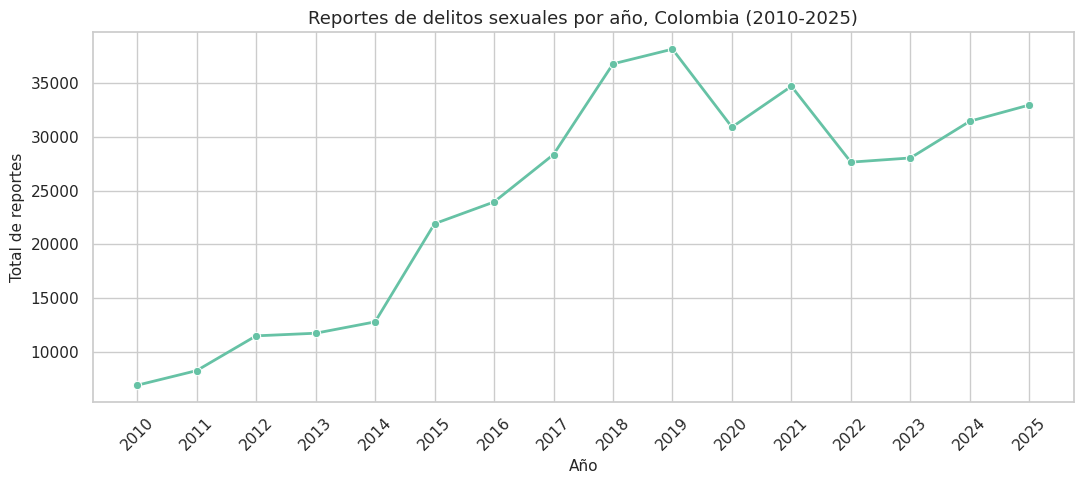

In [14]:
serie_anual_pd = (
    df_2010_2025
    .groupBy("ANIO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .orderBy("ANIO")
    .toPandas()
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=serie_anual_pd, x="ANIO", y="TOTAL_REPORTES", marker="o", linewidth=2)
plt.title("Reportes de delitos sexuales por año, Colombia (2010-2025)")
plt.xlabel("Año")
plt.ylabel("Total de reportes")
plt.xticks(serie_anual_pd["ANIO"], rotation=45)
plt.tight_layout()
plt.show()

En este gráfico se observa un aumento de registros hasta 2019, una reducción en 2020 y variaciones posteriores.

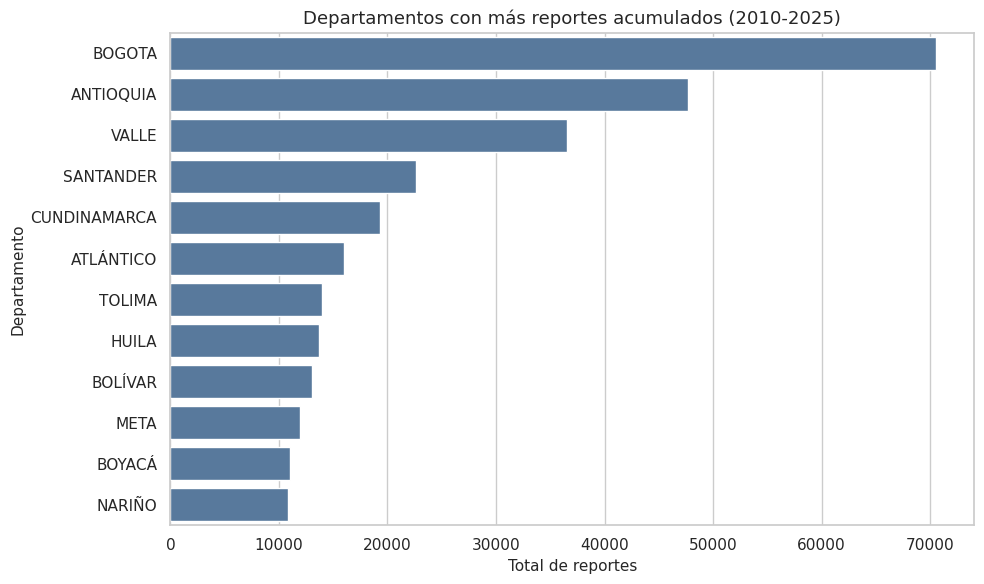

In [15]:
top_deptos_pd = casos_por_departamento.limit(12).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_deptos_pd, y="DEPARTAMENTO", x="TOTAL_REPORTES", color="#4C78A8")
plt.title("Departamentos con más reportes acumulados (2010-2025)")
plt.xlabel("Total de reportes")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

El gráfico de departamentos muestra la concentración territorial. Bogotá, Antioquia y Valle se separan del resto por volumen de reportes.

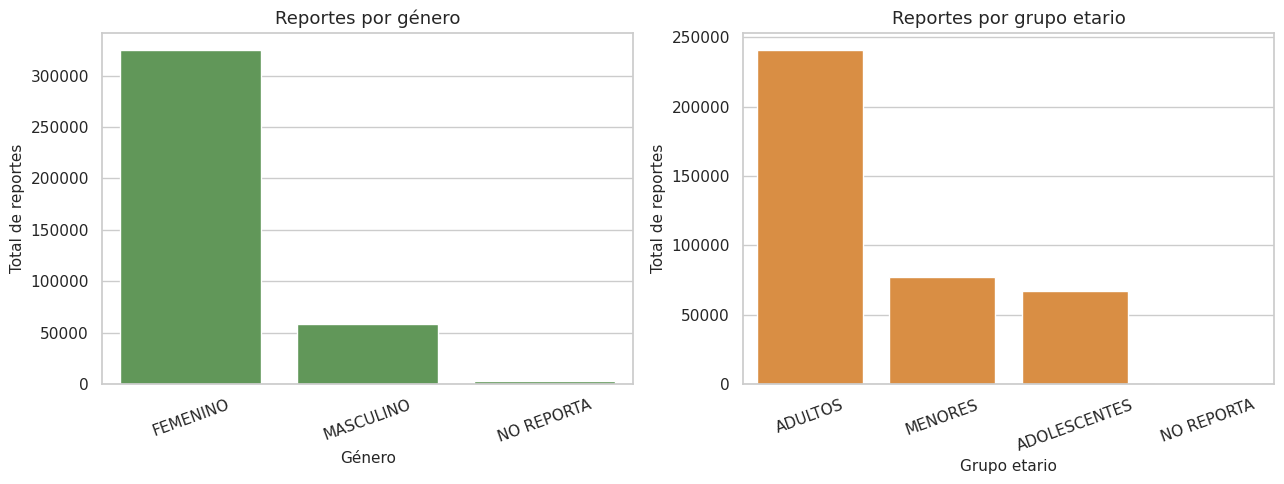

In [16]:
genero_pd = (
    df_2010_2025.groupBy("GENERO_LIMPIO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .orderBy(F.desc("TOTAL_REPORTES"))
    .toPandas()
)

grupo_pd = (
    df_2010_2025.groupBy("GRUPO_ETARIO_LIMPIO")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .orderBy(F.desc("TOTAL_REPORTES"))
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=genero_pd, x="GENERO_LIMPIO", y="TOTAL_REPORTES", ax=axes[0], color="#59A14F")
axes[0].set_title("Reportes por género")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Total de reportes")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=grupo_pd, x="GRUPO_ETARIO_LIMPIO", y="TOTAL_REPORTES", ax=axes[1], color="#F28E2B")
axes[1].set_title("Reportes por grupo etario")
axes[1].set_xlabel("Grupo etario")
axes[1].set_ylabel("Total de reportes")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Los gráficos de género y grupo etario comparan la composición de los registros. La mayor parte de reportes corresponde a género femenino y a adultos.

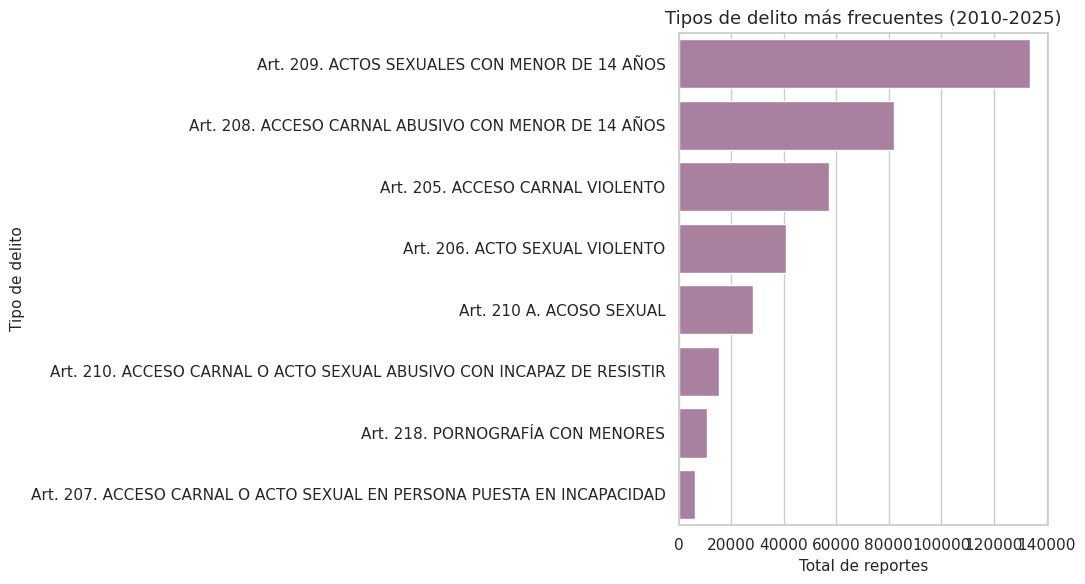

In [17]:
top_delitos_pd = (
    df_2010_2025.groupBy("delito")
    .agg(F.sum("CANTIDAD").alias("TOTAL_REPORTES"))
    .orderBy(F.desc("TOTAL_REPORTES"))
    .limit(8)
    .toPandas()
)

top_delitos_pd["delito_corto"] = top_delitos_pd["delito"].str.replace("ARTÍCULO ", "Art. ", regex=False).str.slice(0, 70)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_delitos_pd, y="delito_corto", x="TOTAL_REPORTES", color="#B07AA1")
plt.title("Tipos de delito más frecuentes (2010-2025)")
plt.xlabel("Total de reportes")
plt.ylabel("Tipo de delito")
plt.tight_layout()
plt.show()

El gráfico de delitos ordena los tipos más frecuentes. Los delitos relacionados con menores de 14 años aparecen en los primeros lugares.

## 9. Preparación de base para el Bloque 2

Se exporta una versión limpia en formato Parquet. Esta base conserva variables útiles para Spark ML: territorio, fecha, género, grupo etario, medio reportado y tipo de delito.

In [18]:
processed_path = DATA_PATH.parent.parent / "processed" / "delitos_sexuales_ml_base.parquet"

df_ml_base = df_2010_2025.select(
    "DEPARTAMENTO", "MUNICIPIO", "CODIGO_DANE", "ARMAS_MEDIOS",
    "GENERO_LIMPIO", "GRUPO_ETARIO_LIMPIO", "delito",
    "CANTIDAD", "ANIO", "MES", "TRIMESTRE"
)

(
    df_ml_base.write
    .mode("overwrite")
    .parquet(str(processed_path))
)

print(f"Base para Bloque 2 guardada en: {processed_path}")

Base para Bloque 2 guardada en: ../data/processed/delitos_sexuales_ml_base.parquet


## 10. Conclusiones cuantitativas

1. Los reportes aumentaron entre 2010 y 2019. En 2010 se registraron 6.887 reportes, mientras que en 2019 se registraron 38.185. Es decir, el número de reportes de 2019 fue más de cinco veces al observado en 2010. Después, en 2020 bajó a 30.922, lo cual puede relacionarse con cambios en denuncia, movilidad, atención institucional o consolidación de registros durante la pandemia.

2. La concentración territorial es alta. Entre 2010 y 2025, Bogotá acumuló 70.515 reportes, Antioquia 47.705 y Valle 36.566. Estos tres territorios suman 154.786 reportes, equivalentes al 40,08% del total del periodo. Esto muestra que una parte importante de los registros se concentra en los territorios con mayor tamaño poblacional y actividad institucional.

3. La mayoría de reportes corresponde a mujeres y a personas adultas, pero los delitos contra menores son relevantes. En 2010-2025, los registros asociados a género femenino fueron 325.377 y los de género masculino 58.138. Por grupo etario, adultos concentró 241.121 reportes, menores 77.540 y adolescentes 67.052. Además, el delito más frecuente fue actos sexuales con menor de 14 años, con 133.818 reportes, lo que evidencia la importancia de analizar la protección de niñas, niños y adolescentes en este fenómeno.

## 11. Limitaciones del análisis

- La base contiene reportes oficiales, no una medición directa de todos los delitos ocurridos.
- El año 2026 está incompleto, por eso se excluyó de las comparaciones anuales principales.
- `CANTIDAD` vale 1 en todos los registros, por lo que el análisis debe hacerse mediante agregaciones.
- Los duplicados exactos no se eliminaron porque pueden representar registros agregados con las mismas características visibles.
- No hay variables de población, coordenadas, contexto del caso ni información socioeconómica, por lo que no se calculan tasas ni explicaciones causales.
- No hay total claridad de cómo se reportaron las variables género y grupo etario, en este trabajo se asume que correponden a los datos de las victimas de los delitos, pero existe cierta inconsitencia entre la cantidad de delitos reportados a menores de edad y la cantidad de adultos.